Download dataset dari kaggle:

In [48]:
!kaggle datasets download revalinaf/food-review-dataset-modul-0-ai-2026 --unzip

^C


Dataset URL: https://www.kaggle.com/datasets/revalinaf/food-review-dataset-modul-0-ai-2026
License(s): unknown




  0%|          | 0.00/5.86M [00:00<?, ?B/s]
 17%|█▋        | 1.00M/5.86M [00:01<00:06, 764kB/s]
 34%|███▍      | 2.00M/5.86M [00:01<00:02, 1.42MB/s]
 51%|█████     | 3.00M/5.86M [00:01<00:01, 2.08MB/s]
 85%|████████▌ | 5.00M/5.86M [00:02<00:00, 3.73MB/s]
100%|██████████| 5.86M/5.86M [00:02<00:00, 4.30MB/s]
100%|██████████| 5.86M/5.86M [00:02<00:00, 2.75MB/s]


# 1. Menentukan fitur apa saja yang relevan dan kolom yang berperan sebagai target variable.

## Target Variable: sentiment_label

Kolom ini merupakan label kategori (ground truth) yang menyatakan sentimen pelanggan(positif,negatif,netral). Ini adalah variabel yang akan kita prediksi berdasarkan input lainnya.

## Fitur yang relevan:

|Kategori|Fitur|Alasan|
|:-----|:------|:---|
|Tekstual|`review_text`|Teks mengandung konteks emosional, keluhan spesifik, dan alasan di balik pemberian rating yang tidak bisa ditangkap oleh angka.|
|Numerik|`rating_taste`, `rating_packaging`, `rating_delivery`, `price`|Memberikan data kuantitatif mengenai aspek mana yang paling memengaruhi kepuasan. `price` membantu model memahami ekspektasi pelanggan (value for money).|
|Kategorikal|`category`, `portion_size`|Kategori makanan menentukan standar ekspektasi. Ukuran porsi sering kali menjadi pemicu utama sentimen negatif jika tidak sesuai dengan harga.|
|Visual|`image_name`|Kolom ini tetap digunakan sebagai fitur untuk memenuhi arsitektur multimodal. Namun terdapat keterbatasan karena penggunaan gambar yang representatif(stock photos). Fitur ini akan diproses melalui tahap ekstraksi visual untuk melengkapi informasi tekstual dan tabular.|

## Fitur yang tidak relevan:

|Fitur|Alasan|
|:-----|:------|
|`review_id`|Hanya identifier unik sistem, tidak mengandung pola perilaku atau sentimen apapun|
|`restaurant_name`, `city`, `food_name`|Jika dimasukkan, model berisiko menjadi bias. Model harus belajar menilai berdasarkan kualitas layanan, bukan nama tempat atau lokasi.|

Risiko data leakage:

|Fitur|Alasan|
|:-----|:------|
|`rating_overall`|Jika diterapkan, maka model hanya akan belajar membaca kolom rating ini tanpa memedulikan ulasan teks atau gambar. Ini membuat model terlihat sangat akurat, tapi gagal total saat diuji pada data baru yang belum memiliki rating.|

# 2. Memahami struktur dataset sebelum analisis lebih lanjut.

In [1]:
import pandas as pd

# path folder
file_path = 'DatasetModul0AI2026/food-review-dataset.csv'

# baca dataset
df = pd.read_csv(file_path)

# identifikasi jumlah data (baris) dan jumlah fitur (kolom)
print("=== Dimensi Dataset ===")
print(f"Jumlah Baris (Data): {df.shape[0]}")
print(f"Jumlah Kolom (Fitur): {df.shape[1]}\n")

# identifikasi tipe data masing-masing kolom dan missing values
print("=== Informasi Struktur Dataset ===")
# df.info() akan menampilkan nama kolom, jumlah data non-null, dan tipe data (int64, float64, object)
df.info()

# cek secara spesifik jumlah data yang kosong (missing Values)
print("\n=== Jumlah Missing Values per Kolom ===")
print(df.isnull().sum())

# lihat statistik deskriptif untuk fitur numerik
print("\n=== Statistik Deskriptif (Numerik) ===")
print(df.describe())

=== Dimensi Dataset ===
Jumlah Baris (Data): 3000
Jumlah Kolom (Fitur): 14

=== Informasi Struktur Dataset ===
<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   review_id         3000 non-null   int64  
 1   restaurant_name   3000 non-null   str    
 2   city              3000 non-null   str    
 3   food_name         3000 non-null   str    
 4   category          3000 non-null   str    
 5   price             3000 non-null   int64  
 6   portion_size      3000 non-null   str    
 7   rating_overall    3000 non-null   int64  
 8   rating_taste      3000 non-null   int64  
 9   rating_packaging  3000 non-null   int64  
 10  rating_delivery   2925 non-null   float64
 11  review_text       2937 non-null   str    
 12  image_name        3000 non-null   str    
 13  sentiment_label   3000 non-null   str    
dtypes: float64(1), int64(5), str(8)
memo

## Dimensi dan kuantitas data:
- Total Data: 3000 baris
- Total Fitur: 14 kolom

## Klasifikasi fitur dan tipe data:
|Kolom|Tipe Data|Klasifikasi Jenis Data|
|:-----|:------|:------|
|`review_id`|`int64`|Metadata|
|`restaurant_name`, `city`, `food_name`, `category`|`str`|Kategorikal(Nominal)|
|`price`|`int64`|Numerik(Kontinu)|
|`portion_size`|`str`|Kategorikal(Ordinal)|
|`rating_overall`, `rating_state`, `rating_packaging`|`int64`|Numerik(Ordinal)|
|`rating_delivery`|`float64`|Numerik(Ordinal)|
|`review_text`|`str`|Teks(Unstructured)|
|`image_name`|`str`|Visual(Reference)|
|`sentiment_label`|`str`|Kategorikal(Target)|

## Analisis kualitas data:
Ditemukan adanya data yang hilang pada dua kolom krusial:
- `rating_delivery`: 75 data kosong (~2.5%)
- `review_text`: 63 data kosong (~2.1%)

## Peran jenis fitur dalam analisis sentimen:
- Fitur numerik: Berperan sebagai sinyal eksplisit

# 3. Menentukan kolom yang digunakan sebagai fitur dan yang berperan sebagai target.

## Penentuan kolom `sentiment_label` sebagai target variable

Alasan:
- Represntasi tujuan: Tujuan utama kita adalah melakukan klasifikasi sentimen (positive,neutral,negative). Kolom ini adalah label ground truth(kunci jawaban) yang mencerminkan hasil akhir dari pengalaman pelanggan.
- Variabel dependen: Dalam pemodelan, kita ingin memprediksi nilai ini berdasarkan variabel-variabel input lainnya.

## Penentuan fitur

- `review_text`(teks): Kata-kata pelanggan mengandung konteks emosional(seperti "kecewa","enak sekali","lambat") yang sangat menentukan label sentimen.
- `rating_taste`, `rating_packaging`, `rating_delivery`(Numerik): Memberikan informasi mendetail mengenai aspek spesifik layanan. Ketiga kolom ini membantu model memahami alasan di balik sentimen.
- `price` dan `portion_size`(Numerik & Kategorikal): Mengukur value for money. Harga mahal dengan porsi kecil sering kali memicu sentimen negatif, begitu juga sebaliknya.
- `category`(Kategorikal): Memberikan konteks standar. Pelanggan mungkin lebih kritis terhadap kategori tertentu.
- `image_name`(Visual): Sebagai data pendukung multimodal untuk memvalidasi kualitas visual produk yang diterima.

## Fitur yang tidak digunakan dan risiko data leakage

- `review_id`: Hanyalah angka acak untuk database. Tidak ada pola perilaku yang bisa dipelajari dari ID unik.
- `restaurant_name` dan `city`: Meskipun terlihat relevan, menggunakan nama restoran atau kota bisa membuat model menjadi bias(overfitting). Kita ingin model yang bisa menilai sentimen secara objektif dari kualitas makanan, bukan karena restoran atau kota punya reputansi tertentu.
- `rating_overall`: Ringkasan matematis yang sangat selaras dengan `sentiment_label`. Risikonya jika fitur ini dimasukkan, model akan hanya membaca rating tanpa berusaha memahami isi teks ulasan atau gambar. Saat model diuji pada ulasan baru yang hanya memiliki teks (tanpa angka rating), performa model akan gagal karena kehilangan jawabannya.

# 4. Analisis fitur numerik untuk melihat distribusi data dan deteksi kemungkinan adanya outlier.

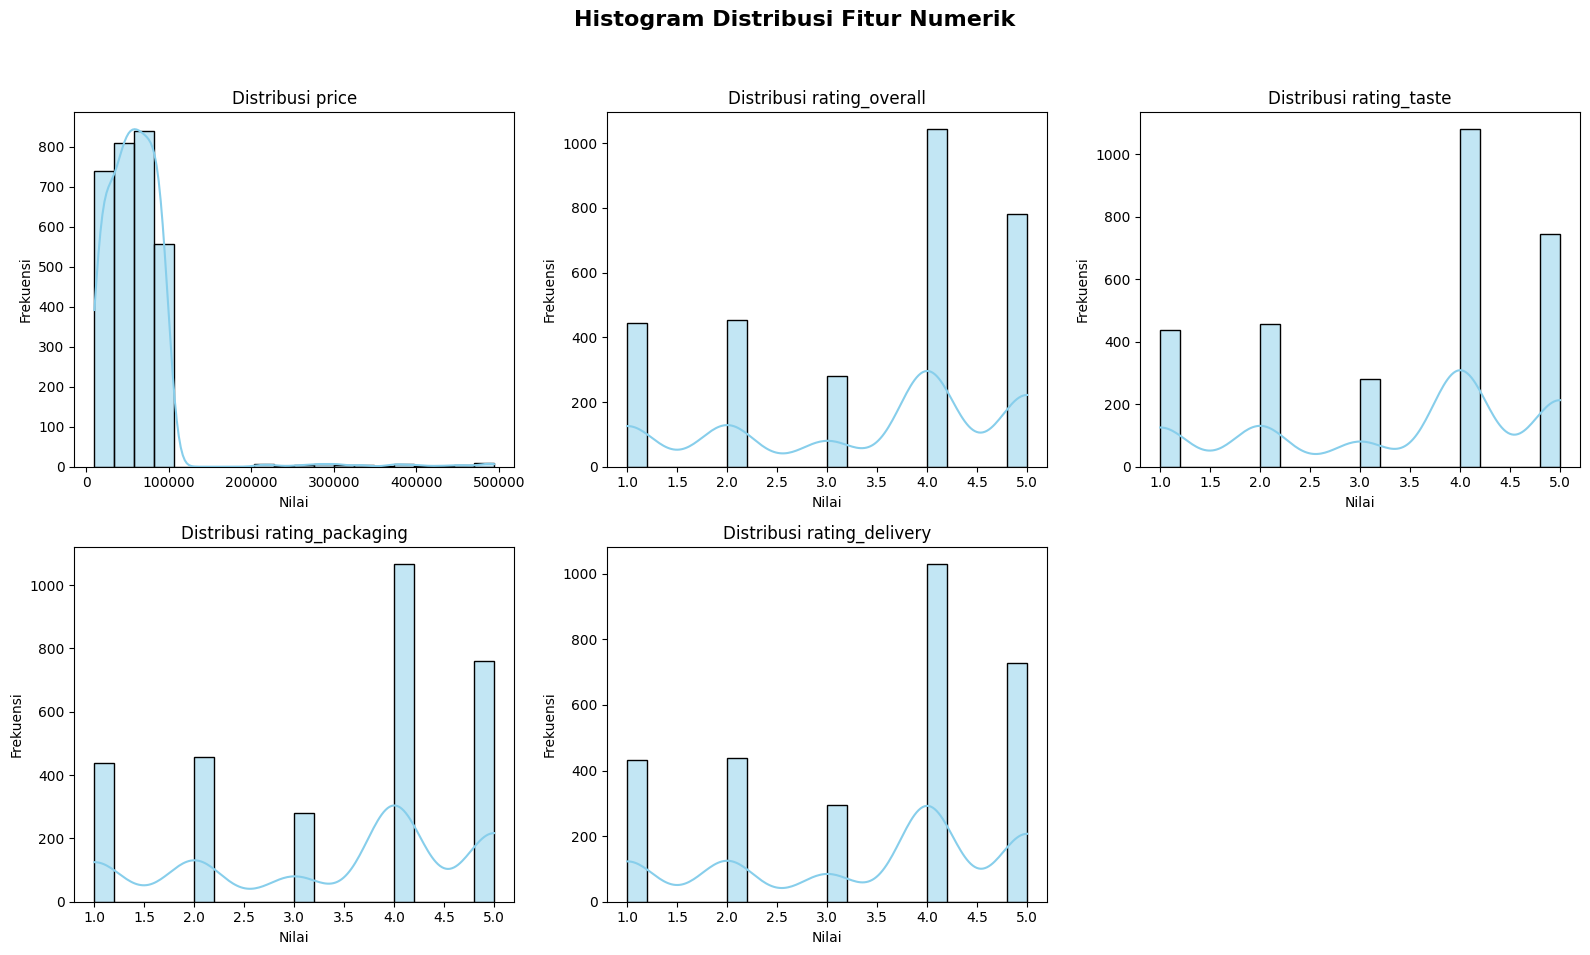

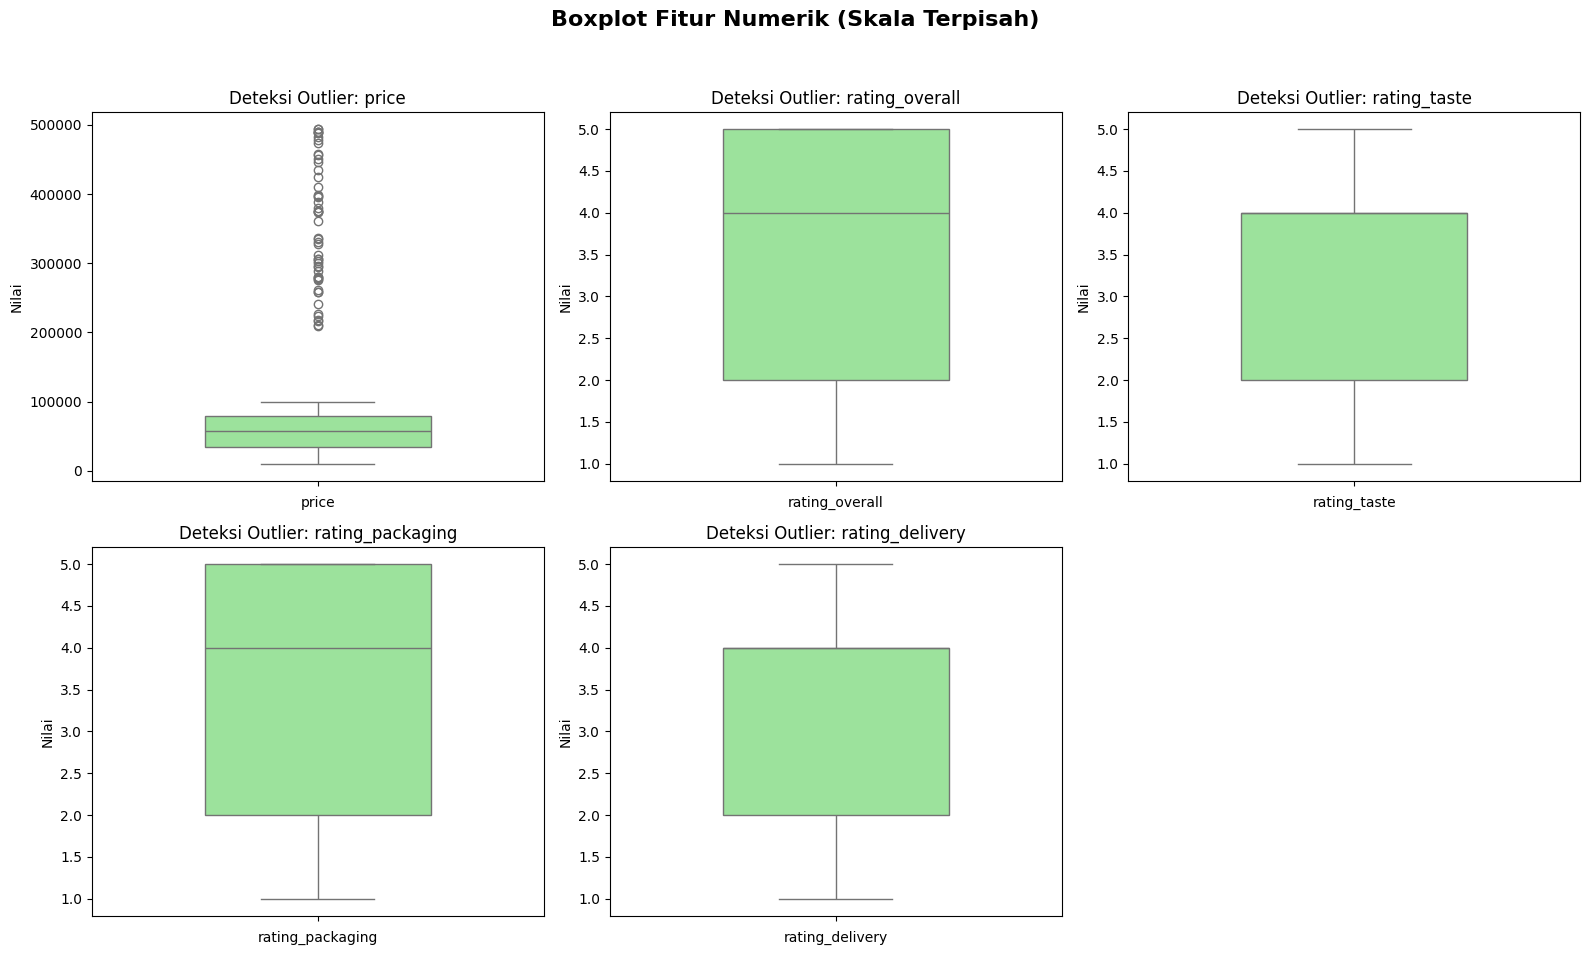

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# daftar fitur numerik
num_features = ['price', 'rating_overall', 'rating_taste', 'rating_packaging', 'rating_delivery']

# visualisasi histogram
plt.figure(figsize=(16, 10))
for i, col in enumerate(num_features):
    plt.subplot(2, 3, i+1)
    # kde=true untuk liat garis tren distribusi
    sns.histplot(df[col], kde=True, color='skyblue', bins=20)
    plt.title(f'Distribusi {col}', fontsize=12)
    plt.xlabel('Nilai')
    plt.ylabel('Frekuensi')

plt.suptitle('Histogram Distribusi Fitur Numerik', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# visualisasi boxpot
# buat subplot agar tiap fitur punya skala Y masing-masing
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.boxplot(y=df[col], ax=axes[i], color='lightgreen', width=0.5)
    axes[i].set_title(f'Deteksi Outlier: {col}', fontsize=12)
    axes[i].set_ylabel('Nilai')
    axes[i].set_xlabel(col)

# hapus subplot ke-6 karena fitur cuma 5
fig.delaxes(axes[-1])

plt.suptitle('Boxplot Fitur Numerik (Skala Terpisah)', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Analisis Distribusi Data
- Fitur rating(1-5): Distribusinya cenderung *skewed* ke arah kanan (banyak nilai 4 dan 5). Tidak ditemukan nilai di luar rentang 1-5, sehingga data rating tergolong bersih secara rentang nilai.
- Fitur harga: Memiliki distribusi yang sangat kebar (*High Variance*). Dengan rata-rata 60.776 dan nilai maksimal 494.038, terlihat adanya ekor panjang (*Long Tail Distribution*) yang menunjukkan adanya beberapa item dengan harga yang jauh di atas rata-rata.

## Identifikasi Outlier dengan Metode Boxplot
Pemeriksaan dilakukan menggunakan metode Interquartile Range (IQR) melalui visualisasi boxplot.

Rumus:
- Hitung $Q1$ (Kuartil 1) dan $Q3$ (Kuartil 3).
- Hitung $IQR = Q3 - Q1$.
- Batas Bawah = $Q1 - 1.5 \times IQR$.
- Batas Atas = $Q3 + 1.5 \times IQR$.

Data yang berada di luar batas bawah dan batas atas dikategorikan sebagai outlier. Pada fitur price, titik-titik yang muncul di atas "kumis" boxplot adalah outliernya.

## Keputusan Penanganan Data
|Fitur|Status Outlier|Keputusan Penanganan|Alasan|
|:-----|:------|:------|:------|
|`price`|Sangat banyak|Winsorization|Nilai ekstrem kemungkinan merupakan harga makanan mewah yang valid, bukan kesalahan input. Winsorization dilakukan untuk menormalisasi distribusi dan memperkecil rentang skala.|
|`rating_overall`, `rating_taste`, `rating_packaging`|Minim|Retain(Dipertahankan)|Nilai rendah (1-2) merupakan sinyal kritis bagi model untuk mempelajari pola ketidakpuasan pelanggan (sentimen negatif).|
|`rating_delivery`,|N/A|Median Imputation|Terdapat 75 baris data kosong. Pengisian dengan nilai median (4.0) dipilih karena distribusinya yang skewed agar tidak mengubah tendensi sentral secara drastis.|

# 5 dan 6. Melakukan preprocessing terhadap data tabular dan teks.

## Data Tabular

In [ ]:
import pandas as pd
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import MinMaxScaler

# load data karena kalau tidak maka akan error
df = pd.read_csv('DatasetModul0AI2026/food-review-dataset.csv')

# penanganan missing values
# isi rating_delivery yang kosong (75 data) dengan median
df['rating_delivery'] = df['rating_delivery'].fillna(df['rating_delivery'].median())

# isi review_text yang kosong (63 data) dengan placeholder agar tidak error saat NLP
df['review_text'] = df['review_text'].fillna("Tidak ada ulasan")

# penanganan outliner
# batasi nilai price pada persentil ke-95 untuk menjinakkan outlier
df['price'] = winsorize(df['price'], limits=[0, 0.05])

# encoding fitur kategorial
# ordinal encoding untuk portion_size (mempertahankan urutan)
portion_map = {'Small': 0, 'Medium': 1, 'Large': 2}
df['portion_size'] = df['portion_size'].map(portion_map)

# one-hot encoding untuk category (nominal/tidak berurutan)
df = pd.get_dummies(df, columns=['category'], prefix='cat')

# feature scaling (min-max scaling)
# fitur yang akan diskalakan ke rentang 0-1
num_cols = ['price', 'rating_taste', 'rating_packaging', 'rating_delivery']

scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# cleanup
# buang fitur yang tidak relevan atau berisiko data leakage
# simpan sentiment_label sebagai target (tidak ikut diskalakan)
cols_to_drop = ['review_id', 'restaurant_name', 'city', 'food_name', 'rating_overall']
df_final = df.drop(columns=cols_to_drop)

print("Preprocessing Selesai!")
print(f"Dimensi dataset baru: {df_final.shape}")
df_final.head()

Preprocessing Selesai!
Dimensi dataset baru: (3000, 15)


,price,portion_size,rating_taste,rating_packaging,rating_delivery,review_text,image_name,sentiment_label,cat_Beverage,cat_Chinese,cat_Dessert,cat_Fast Food,cat_Indian,cat_Indonesian,cat_Japanese
0,0.140722,0,0.75,1.00,0.75,"Makanannya enak banget, bakal order lagi.",img_001.jpg,positive,False,False,False,True,False,False,False
1,0.234180,1,0.50,0.75,0.75,Tidak buruk tapi tidak spesial juga.,img_021.jpg,neutral,False,False,False,False,True,False,False
2,0.833972,2,1.00,0.75,1.00,"Makanannya enak banget, bakal order lagi.",img_004.jpg,positive,False,False,False,True,False,False,False
3,0.419444,0,0.50,0.50,0.50,Standar aja menurutku.,img_019.jpg,neutral,False,False,True,False,False,False,False
4,0.967009,2,0.50,0.75,0.75,Tidak buruk tapi tidak spesial juga.,img_007.jpg,neutral,False,False,False,False,False,False,True


- **Imputasi Median**: Mengisi 75 data kosong pada `rating_delivery`, memastikan model tidak kehilangan baris data penting hanya karena satu kolom tidak terisi.
- **Winsorization**: Dengan "memangkas" harga ekstrem, kita memastikan distribusi harga tidak lagi memiliki ekor yang terlalu panjang.
- **Scaling**: Menggunakan Min-Max Scaling agar semua fitur berada di rentang yang sama. Hal ini penting agar fitur `price` tidak dianggap lebih berpengaruh daripada fitur `rating` oleh model.
- **Encoding**: Mengubah teks menjadi angka memungkinkan operasi matriks dilakukan. Penggunaan `get_dummies` pada `category` memastikan model tidak memberikan bobot hierarki yang salah pada jenis makanan.

# Data Teks

Download package untuk NLTK:

In [65]:
import nltk
import ssl

# bypass SSL jika ada kendala koneksi saat download
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

# download resource yang diperlukan
nltk.download('punkt')
nltk.download('punkt_tab') # tambahkan jika versi NLTK terbaru
nltk.download('stopwords')

print("Resource NLTK berhasil diunduh!")

Resource NLTK berhasil diunduh!


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [66]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re
from sklearn.feature_extraction.text import TfidfVectorizer

# inisialisasi stopwords bahasa indonesia
stop_words = set(stopwords.words('indonesian'))

def clean_text_with_nltk(text):
    # case folding & cleaning
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    
    # tokenization (memecah kalimat menjadi kata-kata)
    tokens = word_tokenize(text)
    
    # stopwords removal (menghapus kata konjungsi yang tidak perlu)
    # filter kata yang panjangnya kurang dari 3 karakter (opsional)
    cleaned_tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    
    # gabungkan kembali menjadi string
    return " ".join(cleaned_tokens)

# terapkan fungsi pada DataFrame
df_final['clean_review'] = df_final['review_text'].apply(clean_text_with_nltk)

# # representasi numerik (TF-IDF)
tfidf = TfidfVectorizer(max_features=500)
tfidf_matrix = tfidf.fit_transform(df_final['clean_review'])

print("Preprocessing Teks dengan NLTK Selesai!")
print(f"Contoh ulasan setelah NLTK: '{df_final['clean_review'].iloc[0]}'")

Preprocessing Teks dengan NLTK Selesai!
Contoh ulasan setelah NLTK: 'makanannya enak banget order'


- **Tokenization yang Akurat**: NLTK memastikan pemisahan kata dilakukan dengan benar, termasuk menangani tanda baca yang menempel pada kata.

- **Stopword Removal**: Menghapus kata-kata fungsional (seperti "yang", "adalah", "ke") yang frekuensinya tinggi tapi tidak membawa sentimen. Ini membantu model untuk fokus pada kata sifat atau kata kerja yang bermakna kuat seperti "kecewa", "lezat", atau "lambat".

- **Efisiensi Fitur**: Dengan menghapus kata-kata yang tidak perlu, dimensi data kita menjadi lebih ramping (sparse matrix yang lebih bersih), sehingga model machine learning tidak akan terganggu oleh "noise" tekstual.

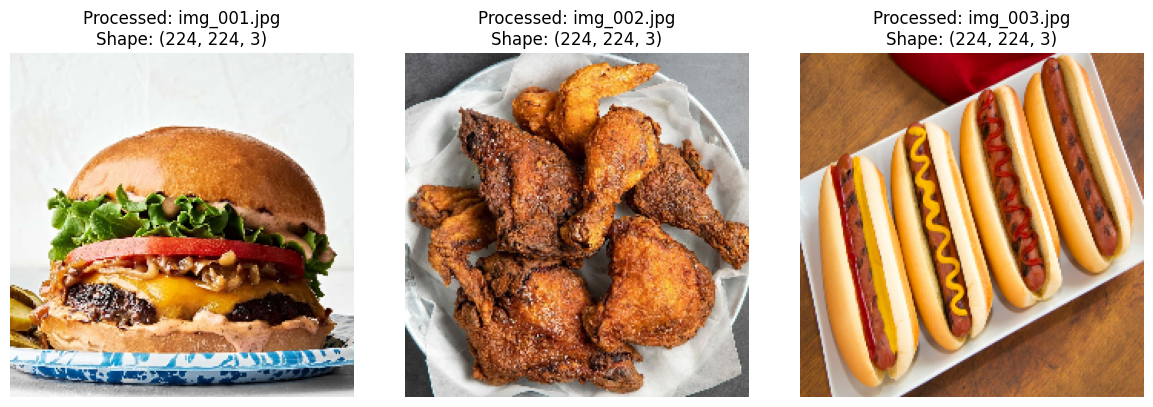

Bentuk data batch citra: (3, 224, 224, 3)


In [ ]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

# tentukan path folder dan ambil sampel nama file
image_dir = 'DatasetModul0AI2026/images/'
sample_images = [f for f in os.listdir(image_dir) if f.endswith('.jpg')][:3] # ambil 3 sampel

processed_images = []

plt.figure(figsize=(12, 4))

for i, img_name in enumerate(sample_images):
    # baca file
    img_path = os.path.join(image_dir, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # konversi bgr ke rgb
    
    # resizing (jadi 224x224)
    img_resized = cv2.resize(img, (224, 224))
    
    # normalisasi (0-255 jadi 0-1)
    img_normalized = img_resized.astype('float32') / 255.0
    
    processed_images.append(img_normalized)
    
    # visualisasi
    plt.subplot(1, 3, i+1)
    plt.imshow(img_normalized)
    plt.title(f"Processed: {img_name}\nShape: {img_normalized.shape}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# konversi list ke array numpy untuk melihat dimensi akhir
image_batch = np.array(processed_images)
print(f"Bentuk data batch citra: {image_batch.shape}")

Setelah melalui proses di atas, data citra yang tadinya berupa file .jpg berubah menjadi matriks angka (array NumPy) dengan struktur:
- Dimensi Single Image: (224, 224, 3)
  - 224, 224: Tinggi dan lebar piksel (resolusi).
  - 3: Channel warna (Red, Green, Blue).

### Pentingnya Tahap Preprocessing Citra
- **Konsistensi Input (Resizing)** : Arsitektur Neural Network memiliki jumlah neuron yang tetap di input layer. Jika satu gambar berukuran 1080p dan lainnya 720p, model tidak akan bisa memprosesnya secara bersamaan dalam satu batch. Resizing memastikan "pintu masuk" model selalu pas.
- **Stabilitas Gradien (Normalization)** : Piksel asli bernilai 0-255. Jika angka besar ini langsung masuk ke model, fungsi aktivasi (seperti Sigmoid atau ReLU) bisa mengalami gradient explosion atau saturation. Mengubahnya ke rentang 0-1 membuat proses kalkulasi bobot (backpropagation) menjadi jauh lebih stabil dan konvergen lebih cepat.
- **Efisiensi Komputasi** : Mengubah tipe data ke float32 dengan skala kecil memudahkan GPU dalam melakukan operasi perkalian matriks yang masif di dalam layer-layer CNN.
- **Standarisasi Warna** : Mengonversi BGR (format standar OpenCV) ke RGB memastikan model mempelajari warna makanan yang natural (Rendang berwarna cokelat, bukan biru karena salah baca channel).